<a href="https://colab.research.google.com/github/cs24dse023-netizen/CSL701-cs23_Machine-Learning-Lab/blob/main/ML_Exp_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


Name : Sandesh Kaskar

Rollno : Cs23 Batch : CS2

## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [ ]:
# Import NumPy for numerical operations
import numpy as np

# Import Pandas for loading and handling the dataset
import pandas as pd

# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Import Seaborn for better-looking plots
import seaborn as sns

# Import train_test_split for splitting the dataset
from sklearn.model_selection import train_test_split

# Import Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Import BaggingClassifier for Task 10
from sklearn.ensemble import BaggingClassifier

# Set random seed so that results are reproducible
np.random.seed(42)

# Set Seaborn plotting style
sns.set_style("whitegrid")


# Define the column names of the Pima Indians Diabetes dataset
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]


# Load the dataset
df = pd.read_csv(
    "/content/diabetes.csv",
    header=None,
    names=columns
)


# Display the first five rows of the dataset
print("First five records:")
print(df.head())


# Display the number of rows and columns
print("Dataset shape:")
print(df.shape)

# Display the number of rows and columns
print("Dataset shape:")
print(df.shape)

# Display the data type of every column
print("Data types:")
print(df.dtypes)


# Display statistical information about numerical columns
print("Descriptive statistics:")
print(df.describe())








First five records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI   
1            6      148             72             35    169.5  33.6   
2            1       85             66             29    102.5  26.6   
3            8      183             64             32    169.5  23.3   
4            1       89             66             23       94  28.1   

   DiabetesPedigreeFunction  Age  Outcome  
0  DiabetesPedigreeFunction  Age  Outcome  
1                     0.627   50        1  
2                     0.351   31        0  
3                     0.672   32        1  
4                     0.167   21        0  
Dataset shape:
(769, 9)
Dataset shape:
(769, 9)
Data types:
Pregnancies                 object
Glucose                     object
BloodPressure               object
SkinThickness               object
Insulin                     object
BMI                         object
DiabetesPedig

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Non-Diabetic patients: 500
Diabetic patients: 267
Non-Diabetic percentage: 65.19 %
Diabetic percentage: 34.81 %


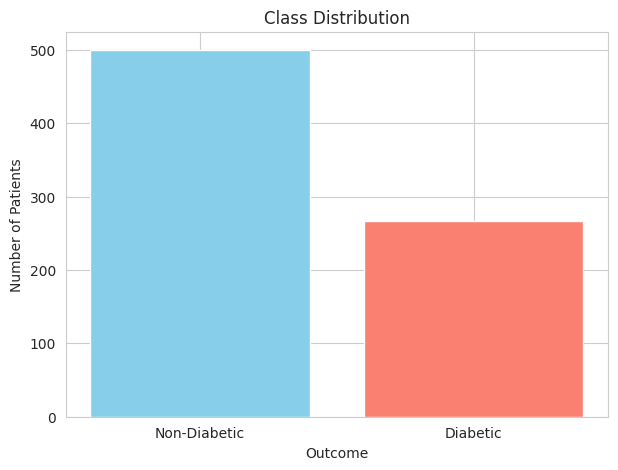

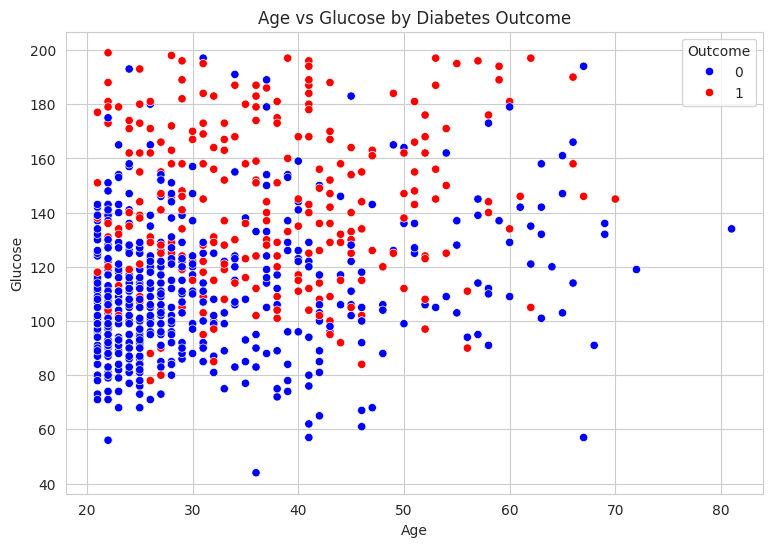

In [ ]:
# Drop the header row that was incorrectly loaded as data
df = df.iloc[1:].copy()

# Convert relevant columns to numeric type
df["Outcome"] = pd.to_numeric(df["Outcome"])
df["Age"] = pd.to_numeric(df["Age"])
df["Glucose"] = pd.to_numeric(df["Glucose"])

# Count the number of patients in each class
class_counts = df["Outcome"].value_counts().sort_index()

# Display the number of non-diabetic patients
print("Non-Diabetic patients:", class_counts[0])

# Display the number of diabetic patients
print("Diabetic patients:", class_counts[1])

# Calculate the percentage of each class
class_percentages = (
    df["Outcome"].value_counts(normalize=True).sort_index() * 100
)

# Display percentage of non-diabetic patients
print("Non-Diabetic percentage:",
      round(class_percentages[0], 2), "%")

# Display percentage of diabetic patients
print("Diabetic percentage:",
      round(class_percentages[1], 2), "%")

# Create a bar chart for class distribution
plt.figure(figsize=(7, 5))

# Create the bar plot
plt.bar(
    ["Non-Diabetic", "Diabetic"],
    [class_counts[0], class_counts[1]],
    color=["skyblue", "salmon"]
)

# Add title
plt.title("Class Distribution")

# Add x-axis label
plt.xlabel("Outcome")

# Add y-axis label
plt.ylabel("Number of Patients")

# Display the graph
plt.show()

# Create a figure
plt.figure(figsize=(9, 6))

# Plot Age against Glucose
# Different colors are used for different outcomes
sns.scatterplot(
    data=df,
    x="Age",
    y="Glucose",
    hue="Outcome",
    palette={0: "blue", 1: "red"}
)

# Add graph title
plt.title("Age vs Glucose by Diabetes Outcome")

# Add x-axis label
plt.xlabel("Age")

# Add y-axis label
plt.ylabel("Glucose")

# Display the graph
plt.show()

# A simple linear decision boundary is insufficient because diabetic and
#  non-diabetic patients overlap in the Age-Glucose feature space.
# Diabetes depends on several variables simultaneously, such as glucose,
# BMI, age, pregnancies, and DiabetesPedigreeFunction. Their relationships
# may be nonlinear. Therefore, a Decision Tree is more suitable because it
# can create nonlinear decision boundaries.

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [ ]:
# These features cannot realistically have a value of zero
invalid_zero_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Create a copy so that the original dataset remains unchanged
df_clean = df.copy()

# List of all feature columns that should be numeric (excluding 'Glucose', 'Age', 'Outcome'
# which were already converted in the previous cell)
numeric_features_to_convert = [
    "Pregnancies",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction"
]

# Convert these columns to numeric type, coercing errors to NaN
for col in numeric_features_to_convert:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Check how many zero values exist in each invalid feature
for column in invalid_zero_features:
    # Count zero values in the current column (now numeric)
    zero_count = (df_clean[column] == 0).sum()

    # Display the result
    print(column, ":", zero_count)

    # Replace invalid zero values with NaN
    # NaN represents a missing value
    df_clean[column] = df_clean[column].replace(0, np.nan)


# Display the number of missing values in every column
print("Missing values after replacing zero:")
print(df_clean.isnull().sum())


# Replace missing values with the median of each feature
# Median is less affected by outliers than the mean
for column in invalid_zero_features:
    # Calculate median and fill missing values
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

# Check whether any missing values remain
print("Missing values after median imputation:")
print(df_clean.isnull().sum())


Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0
Missing values after replacing zero:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [ ]:
# X contains the first 8 predictor variables
X = df_clean.drop("Outcome", axis=1)

# y contains the target variable
y = df_clean["Outcome"]

# Display the shape of X
print("X shape:", X.shape)

# Display the shape of y
print("y shape:", y.shape)

# Split the dataset into:
# 80% training data
# 20% testing data
#
# stratify=y keeps the class proportions similar
# in both training and testing datasets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Display training and testing dimensions

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)


# Display class proportions in training data
print("Training class proportions:")
print(y_train.value_counts(normalize=True))

# Display class proportions in testing data
print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True))




X shape: (767, 8)
y shape: (767,)
Training features: (613, 8)
Testing features: (154, 8)
Training target: (613,)
Testing target: (154,)
Training class proportions:
Outcome
0    0.652529
1    0.347471
Name: proportion, dtype: float64

Testing class proportions:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [ ]:
# Define a function to create a bootstrap sample
def get_bootstrap_sample(X, y):

    # Get the number of training samples
    n_samples = len(X)

    # Randomly select n_samples indices
    # replace=True means sampling is done WITH replacement
    indices = np.random.choice(
        n_samples,
        size=n_samples,
        replace=True
    )

    # Create bootstrap feature dataset
    X_bootstrap = X.iloc[indices].copy()

    # Create bootstrap target dataset
    y_bootstrap = y.iloc[indices].copy()

    # Return bootstrap data and selected indices
    return X_bootstrap, y_bootstrap, indices


    # Generate one bootstrap sample
X_bootstrap, y_bootstrap, bootstrap_indices = (
    get_bootstrap_sample(
        X_train,
        y_train
    )
)

# Display original training size
print("Original training size:", len(X_train))

# Display bootstrap training size
print("Bootstrap training size:", len(X_bootstrap))


# Find unique indices and the number of times each appears
unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

# Select indices that occur more than once
duplicated_indices = unique_indices[counts > 1]

# Display duplicated samples
print("Number of duplicated indices:",
      len(duplicated_indices))

print("Some duplicated indices:")
print(duplicated_indices[:10])

# Create a set containing all original training indices
all_indices = set(range(len(X_train)))

# Create a set containing selected bootstrap indices
selected_indices = set(bootstrap_indices)

# OOB samples are original samples that were not selected
oob_indices = sorted(
    all_indices - selected_indices
)

# Display number of OOB samples
print("Number of OOB samples:", len(oob_indices))

# Display some OOB indices
print("Some OOB indices:")
print(oob_indices[:10])





Original training size: 613
Bootstrap training size: 613
Number of duplicated indices: 163
Some duplicated indices:
[ 0  1  2  6  9 10 11 13 16 19]
Number of OOB samples: 234
Some OOB indices:
[3, 4, 5, 12, 14, 15, 17, 22, 24, 29]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [ ]:
# Number of decision trees in our Bagging ensemble
B = 50
# Create an empty list to store trained decision trees
ensemble = []
# Repeat the bootstrap and training process 50 times
for b in range(B):

    # Generate a new bootstrap sample
    X_bootstrap, y_bootstrap, _ = (
        get_bootstrap_sample(
            X_train,
            y_train
        )
    )

    # Create a fully-grown Decision Tree
    # max_depth=None means no maximum depth
    tree = DecisionTreeClassifier(
        max_depth=None,
        random_state=42 + b
    )

    # Train the tree using the bootstrap sample
    tree.fit(
        X_bootstrap,
        y_bootstrap
    )

    # Add the trained tree to the ensemble
    ensemble.append(tree)

    # Display the number of trained trees
print("Number of trees:", len(ensemble))


# Display the number of trained trees
print("Number of trees:", len(ensemble))



Number of trees: 50
Number of trees: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [ ]:
# Define a function for majority voting
def custom_bagging_predict(ensemble, X_test):

    # Create an empty list to store predictions
    # from every decision tree
    all_predictions = []

    # Get predictions from each tree
    for model in ensemble:

        # Predict test samples
        predictions = model.predict(X_test)

        # Store predictions
        all_predictions.append(predictions)

    # Convert list to NumPy array
    all_predictions = np.array(all_predictions)

    # Create list for final predictions
    final_predictions = []

    # Process each test sample
    for i in range(X_test.shape[0]):

        # Get votes from all trees for sample i
        votes = all_predictions[:, i]

        # Count votes for class 0
        count_class_0 = np.sum(votes == 0)

        # Count votes for class 1
        count_class_1 = np.sum(votes == 1)

        # Select class with the majority of votes
        if count_class_1 > count_class_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    # Return final majority-voted predictions
    return np.array(final_predictions)


    # Use our custom Bagging function to predict the test set
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

# Display the first 20 predictions
print("First 20 Bagging predictions:")
print(y_pred_bagging[:20])



First 20 Bagging predictions:
[0 0 0 1 0 0 0 1 0 1 0 1 0 0 1 1 0 0 1 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

Single Decision Tree Confusion Matrix:
[[91  9]
 [16 38]]
Custom Bagging Confusion Matrix:
[[93  7]
 [15 39]]
===== SINGLE DECISION TREE =====
Accuracy : 0.8377
Precision: 0.8085
Recall   : 0.7037
F1-Score : 0.7525

===== CUSTOM BAGGING =====
Accuracy : 0.8571
Precision: 0.8478
Recall   : 0.7222
F1-Score : 0.78
                  Model  Accuracy  Precision    Recall  F1-Score
0  Single Decision Tree  0.837662   0.808511  0.703704  0.752475
1        Custom Bagging  0.857143   0.847826  0.722222  0.780000


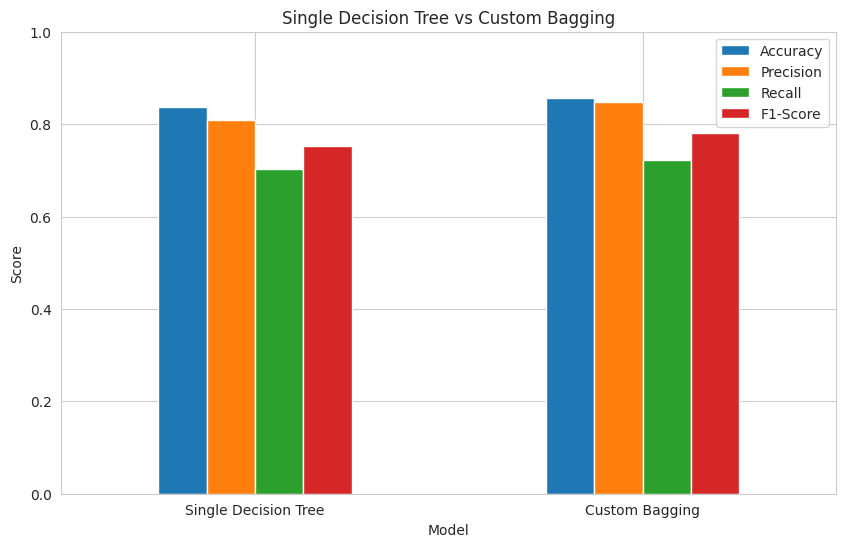

In [ ]:
# Create a single fully-grown Decision Tree
single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Train the tree on the original training data
single_tree.fit(
    X_train,
    y_train
)

# Predict the test dataset using the single tree
y_pred_tree = single_tree.predict(
    X_test
)

# Predict the test dataset using our custom Bagging ensemble
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

# Calculate confusion matrix for single tree
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

# Display the confusion matrix
print("Single Decision Tree Confusion Matrix:")
print(cm_tree)


# Calculate confusion matrix for Bagging
cm_bagging = confusion_matrix(
    y_test,
    y_pred_bagging
)

# Display the confusion matrix
print("Custom Bagging Confusion Matrix:")
print(cm_bagging)


# Calculate accuracy of single tree
accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)

# Calculate precision of single tree
precision_tree = precision_score(
    y_test,
    y_pred_tree
)

# Calculate recall of single tree
recall_tree = recall_score(
    y_test,
    y_pred_tree
)

# Calculate F1-score of single tree
f1_tree = f1_score(
    y_test,
    y_pred_tree
)

# Calculate accuracy of Bagging
accuracy_bagging = accuracy_score(
    y_test,
    y_pred_bagging
)

# Calculate precision of Bagging
precision_bagging = precision_score(
    y_test,
    y_pred_bagging
)

# Calculate recall of Bagging
recall_bagging = recall_score(
    y_test,
    y_pred_bagging
)

# Calculate F1-score of Bagging
f1_bagging = f1_score(
    y_test,
    y_pred_bagging
)


# Display metrics for Single Decision Tree
print("===== SINGLE DECISION TREE =====")

print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1-Score :", round(f1_tree, 4))


# Display metrics for Custom Bagging
print("\n===== CUSTOM BAGGING =====")

print("Accuracy :", round(accuracy_bagging, 4))
print("Precision:", round(precision_bagging, 4))
print("Recall   :", round(recall_bagging, 4))
print("F1-Score :", round(f1_bagging, 4))

# Create a DataFrame for comparing both models
comparison = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Custom Bagging"
    ],

    "Accuracy": [
        accuracy_tree,
        accuracy_bagging
    ],

    "Precision": [
        precision_tree,
        precision_bagging
    ],

    "Recall": [
        recall_tree,
        recall_bagging
    ],

    "F1-Score": [
        f1_tree,
        f1_bagging
    ]
})

# Display comparison table
print(comparison)


# Create bar chart of model performance
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

# Add title
plt.title("Single Decision Tree vs Custom Bagging")

# Add y-axis label
plt.ylabel("Score")

# Scores range from 0 to 1
plt.ylim(0, 1)

# Keep model names horizontal
plt.xticks(rotation=0)

# Display graph
plt.show()



#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Probability array shape:
(50, 154)
Single Decision Tree AUC: 0.8069
Custom Bagging AUC: 0.9075


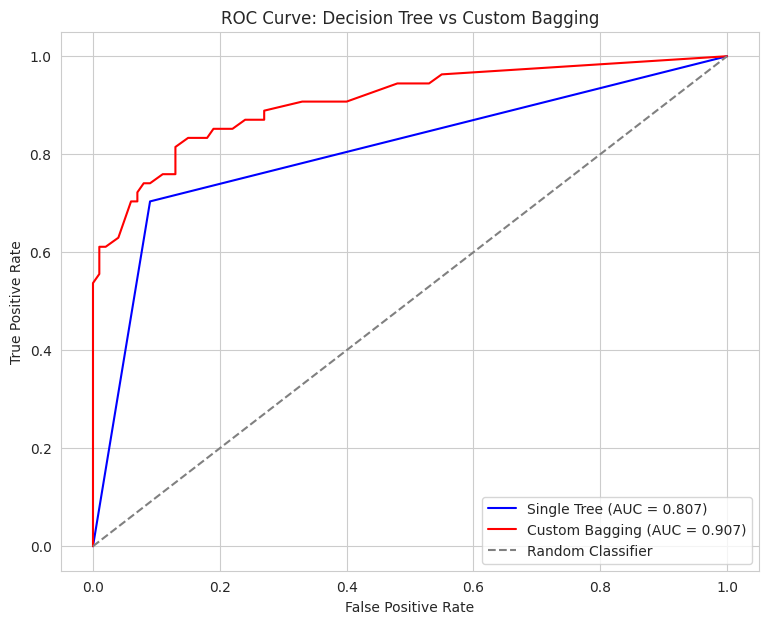

In [ ]:
# Get probability predictions from the single tree
# [:, 1] selects the probability of class 1 (diabetic)
y_prob_tree = single_tree.predict_proba(
    X_test
)[:, 1]

# Create an empty list to store probabilities
all_probabilities = []

# Loop through every tree in the ensemble
for model in ensemble:

    # Get probability of class 1
    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    # Store probabilities
    all_probabilities.append(
        probabilities
    )

# Convert the list of probabilities into a NumPy array
all_probabilities = np.array(
    all_probabilities
)

# Display the shape
print("Probability array shape:")
print(all_probabilities.shape)


# Average the probabilities from all 50 trees
# This gives the final Bagging probability
y_prob_bagging = np.mean(
    all_probabilities,
    axis=0
)


# Calculate AUC for single Decision Tree
auc_tree = roc_auc_score(
    y_test,
    y_prob_tree
)

# Calculate AUC for custom Bagging
auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)

# Display AUC values
print("Single Decision Tree AUC:",
      round(auc_tree, 4))

print("Custom Bagging AUC:",
      round(auc_bagging, 4))


# Calculate ROC curve for the single tree
fpr_tree, tpr_tree, thresholds_tree = roc_curve(
    y_test,
    y_prob_tree
)

# Calculate ROC curve for Bagging
fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    y_prob_bagging
)

# Create ROC plot
plt.figure(figsize=(9, 7))

# Plot Single Decision Tree ROC curve
plt.plot(
    fpr_tree,
    tpr_tree,
    color="blue",
    label=f"Single Tree (AUC = {auc_tree:.3f})"
)

# Plot Bagging ROC curve
plt.plot(
    fpr_bagging,
    tpr_bagging,
    color="red",
    label=f"Custom Bagging (AUC = {auc_bagging:.3f})"
)

# Plot random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

# Add x-axis label
plt.xlabel("False Positive Rate")

# Add y-axis label
plt.ylabel("True Positive Rate")

# Add title
plt.title("ROC Curve: Decision Tree vs Custom Bagging")

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Show graph
plt.show()



#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

Scikit-Learn Bagging Accuracy: 0.8571
Scikit-Learn Bagging Confusion Matrix:
[[93  7]
 [15 39]]
Accuracy : 0.8571
Precision: 0.8478
Recall   : 0.7222
F1-Score : 0.78
                  Model  Accuracy  Precision    Recall  F1-Score
0  Single Decision Tree  0.837662   0.808511  0.703704  0.752475
1        Custom Bagging  0.857143   0.847826  0.722222  0.780000
2  Scikit-Learn Bagging  0.857143   0.847826  0.722222  0.780000


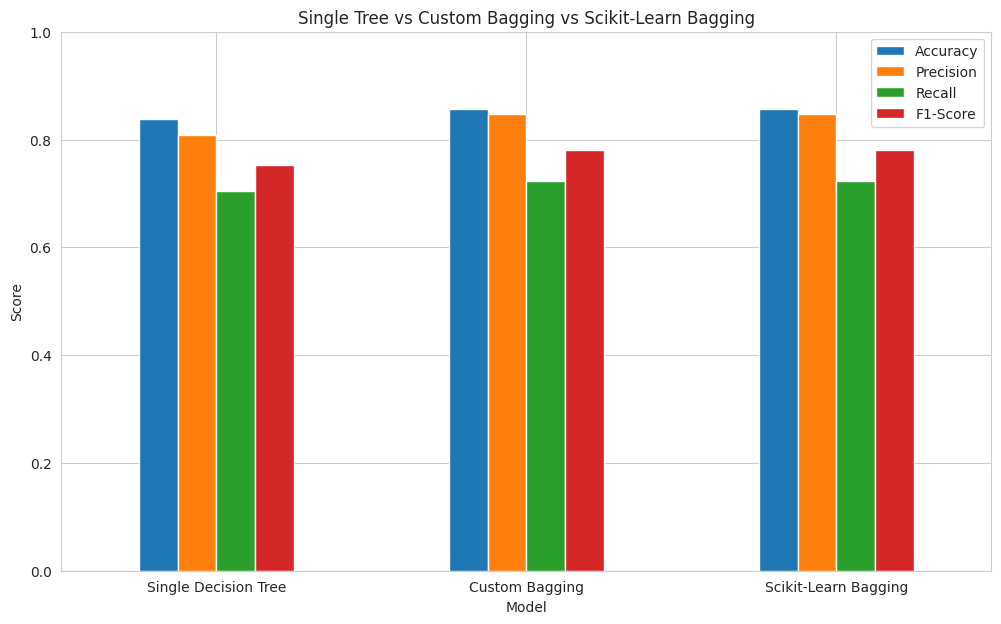

In [ ]:
# Create the base Decision Tree
base_tree = DecisionTreeClassifier(
    max_depth=None
)

# Create Scikit-Learn Bagging classifier
sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    random_state=42
)


# Train Scikit-Learn Bagging classifier
sklearn_bagging.fit(
    X_train,
    y_train
)


# Predict the test dataset
y_pred_sklearn = sklearn_bagging.predict(
    X_test
)


# Calculate accuracy of Scikit-Learn Bagging
accuracy_sklearn = accuracy_score(
    y_test,
    y_pred_sklearn
)

# Display accuracy
print("Scikit-Learn Bagging Accuracy:",
      round(accuracy_sklearn, 4))


# Calculate confusion matrix
cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)

# Display confusion matrix
print("Scikit-Learn Bagging Confusion Matrix:")
print(cm_sklearn)


# Calculate precision
precision_sklearn = precision_score(
    y_test,
    y_pred_sklearn
)

# Calculate recall
recall_sklearn = recall_score(
    y_test,
    y_pred_sklearn
)

# Calculate F1-score
f1_sklearn = f1_score(
    y_test,
    y_pred_sklearn
)

# Display all metrics
print("Accuracy :", round(accuracy_sklearn, 4))
print("Precision:", round(precision_sklearn, 4))
print("Recall   :", round(recall_sklearn, 4))
print("F1-Score :", round(f1_sklearn, 4))

# Create final comparison table
final_comparison = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Custom Bagging",
        "Scikit-Learn Bagging"
    ],

    "Accuracy": [
        accuracy_tree,
        accuracy_bagging,
        accuracy_sklearn
    ],

    "Precision": [
        precision_tree,
        precision_bagging,
        precision_sklearn
    ],

    "Recall": [
        recall_tree,
        recall_bagging,
        recall_sklearn
    ],

    "F1-Score": [
        f1_tree,
        f1_bagging,
        f1_sklearn
    ]
})

# Display final comparison
print(final_comparison)


# Set Model as the index
final_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(12, 7)
)

# Add title
plt.title(
    "Single Tree vs Custom Bagging vs Scikit-Learn Bagging"
)

# Add y-axis label
plt.ylabel("Score")

# Set score range
plt.ylim(0, 1)

# Keep model names horizontal
plt.xticks(rotation=0)

# Display legend
plt.legend()

# Display graph
plt.show()


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?